# Bayesian Logistic 回归：MCMC 与变分推断代码

整个代码的任务大概如下：

1. 定义模型、先验、后验和梯度；
2. 实现五种 MCMC 方法：随机游动 MH、逐分量 MH、多元正态建议分布 MH、切片 Gibbs、HMC；
3. 实现两种变分推断方法：重参数化梯度和 Score Function 梯度；
4. 输出参数估计、HPD 区间、MCSE、Gelman--Rubin 诊断；
5. 可视化。

运行后结果会保存到：

```text
final_results/
final_results/figures/
```


## Cell 1：调入包、录入数据

本单元导入实验所需的 Python 包(注意环境为Stanford的ISLP环境)，并录入题中的 54 个观测数据。


In [1]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import minimize
from scipy.stats import gaussian_kde
import torch
import torch.nn.functional as F

# 固定随机种子
np.random.seed(2026)
torch.manual_seed(2026)
torch.set_default_dtype(torch.float64)

RESULT_DIR = "final_results"
FIG_DIR = os.path.join(RESULT_DIR, "figures")
os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# 数据：x 为智力测试分数，y 为是否患病
x = np.array([
    9, 13, 6, 8, 10, 4, 14, 8, 11, 7, 9, 7, 5, 14,
    13, 16, 10, 12, 11, 14, 15, 18, 7, 16, 9, 9, 11, 13,
    15, 13, 10, 11, 6, 17, 14, 19, 9, 11, 14, 10, 16, 10,
    16, 14, 13, 13, 9, 15, 10, 11, 12, 4, 14, 20
], dtype=float)

y = np.array([
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
], dtype=float)

n = len(x)
X = np.column_stack([np.ones(n), x])

prior_sd = 100.0
prior_var = prior_sd ** 2

print("样本量 n =", n)
print("患病人数 =", int(y.sum()))
print("未患病人数 =", int(n - y.sum()))
print("x 的均值 =", x.mean())
print("x 的标准差 =", x.std())


样本量 n = 54
患病人数 = 14
未患病人数 = 40
x 的均值 = 11.574074074074074
x 的标准差 = 3.674747922077014


## Cell 2：定义对数似然、先验、后验和梯度

本单元定义 Bayesian logistic 回归中需要的基础函数。MCMC 只需要计算与后验成比例的对数密度；HMC 额外需要后验对数密度的梯度。


In [2]:
def sigmoid(z):
    """sigmoid 函数。"""
    return 1 / (1 + np.exp(-z))


def loglik(beta):
    """logistic 回归对数似然。"""
    eta = X @ beta
    return np.sum(y * eta - np.logaddexp(0, eta))


def grad_loglik(beta):
    """logistic 回归对数似然的梯度。"""
    eta = X @ beta
    p = sigmoid(eta)
    return X.T @ (y - p)


def logprior(beta):
    """独立正态先验的对数密度。"""
    return np.sum(
        -0.5 * beta ** 2 / prior_var
        - np.log(prior_sd)
        - 0.5 * np.log(2 * np.pi)
    )


def grad_logprior(beta):
    """独立正态先验对数密度的梯度。"""
    return -beta / prior_var


def logpost(beta):
    """后验对数密度，（差一个常数不影响） MCMC。"""
    return loglik(beta) + logprior(beta)


def grad_logpost(beta):
    """后验对数密度梯度。"""
    return grad_loglik(beta) + grad_logprior(beta)


## Cell 3：计算 MAP 和近似后验协方差

这部分我使用了最优化课程里学过的拟牛顿法 BFGS 代替牛顿迭代求后验众数 MAP。MAP 用来设置 MCMC 初始值，也用于构造多元正态建议分布。


In [3]:
def neg_logpost(beta):
    return -logpost(beta)


def neg_grad_logpost(beta):
    return -grad_logpost(beta)


res = minimize(
    fun=neg_logpost,
    x0=np.array([0.0, 0.0]),
    jac=neg_grad_logpost,
    method="BFGS"
)

beta_map = res.x
cov_map = np.asarray(res.hess_inv)
sd_map = np.sqrt(np.diag(cov_map))

print("MAP =", beta_map)
print("近似后验标准差 =", sd_map)
print("近似后验协方差矩阵：")
print(cov_map)
print("优化是否成功：", res.success)


MAP = [ 2.40369769 -0.32349873]
近似后验标准差 = [1.19055552 0.11371413]
近似后验协方差矩阵：
[[ 1.41742246 -0.12954693]
 [-0.12954693  0.0129309 ]]
优化是否成功： True


## Cell 4：定义五种 MCMC 算法

五种采样方法：

1. 随机游动 Metropolis--Hastings；
2. 逐分量 Metropolis--Hastings；
3. 多元正态独立建议分布 Metropolis--Hastings；
4. 切片 Gibbs；
5. Hamiltonian Monte Carlo。



In [4]:
def random_walk_mh(N, init, prop_sd):
    """随机游动 Metropolis-Hastings。"""
    chain = np.zeros((N, 2))
    beta = init.copy()
    logp = logpost(beta)
    accept = 0

    for t in range(N):
        beta_new = beta + np.random.normal(0, prop_sd, size=2)
        logp_new = logpost(beta_new)

        if np.log(np.random.rand()) < logp_new - logp:
            beta = beta_new
            logp = logp_new
            accept += 1

        chain[t] = beta

    return chain, accept / N


def component_mh(N, init, prop_sd):
    """逐分量 Metropolis-Hastings。"""
    chain = np.zeros((N, 2))
    beta = init.copy()
    logp = logpost(beta)
    accept = np.zeros(2)

    for t in range(N):
        for j in range(2):
            beta_new = beta.copy()
            beta_new[j] += np.random.normal(0, prop_sd[j])
            logp_new = logpost(beta_new)

            if np.log(np.random.rand()) < logp_new - logp:
                beta = beta_new
                logp = logp_new
                accept[j] += 1

        chain[t] = beta

    return chain, accept / N


def log_mvn_pdf(z, mean, cov):
    """多元正态分布 log density。"""
    z = np.asarray(z)
    mean = np.asarray(mean)
    d = len(mean)
    diff = z - mean
    inv_cov = np.linalg.inv(cov)
    sign, logdet = np.linalg.slogdet(cov)
    if sign <= 0:
        raise ValueError("cov 必须为正定矩阵。")
    return -0.5 * (d * np.log(2 * np.pi) + logdet + diff @ inv_cov @ diff)


def independent_mvn_mh(N, init, q_mean, q_cov):
    """多元正态独立建议分布 MH。"""
    chain = np.zeros((N, 2))
    beta = init.copy()
    logp = logpost(beta)
    logq = log_mvn_pdf(beta, q_mean, q_cov)
    accept = 0

    for t in range(N):
        beta_new = np.random.multivariate_normal(q_mean, q_cov)
        logp_new = logpost(beta_new)
        logq_new = log_mvn_pdf(beta_new, q_mean, q_cov)

        # independence proposal 的 MH 接受率
        log_alpha = logp_new + logq - logp - logq_new

        if np.log(np.random.rand()) < log_alpha:
            beta = beta_new
            logp = logp_new
            logq = logq_new
            accept += 1

        chain[t] = beta

    return chain, accept / N


def slice_one_dim(x0, logf, w=1.0, m=50):
    """一维切片采样：stepping-out + shrinkage。"""
    logy = logf(x0) - np.random.exponential(1)

    u = np.random.rand()
    L = x0 - u * w
    R = L + w

    J = int(m * np.random.rand())
    K = m - 1 - J

    while J > 0 and logf(L) > logy:
        L -= w
        J -= 1

    while K > 0 and logf(R) > logy:
        R += w
        K -= 1

    while True:
        x1 = np.random.uniform(L, R)
        if logf(x1) >= logy:
            return x1
        if x1 < x0:
            L = x1
        else:
            R = x1


def slice_gibbs(N, init, widths):
    """逐分量切片 Gibbs。"""
    chain = np.zeros((N, 2))
    beta = init.copy()

    for t in range(N):
        beta1_fixed = beta[1]
        beta[0] = slice_one_dim(
            beta[0],
            lambda b0: logpost(np.array([b0, beta1_fixed])),
            w=widths[0]
        )

        beta0_fixed = beta[0]
        beta[1] = slice_one_dim(
            beta[1],
            lambda b1: logpost(np.array([beta0_fixed, b1])),
            w=widths[1]
        )

        chain[t] = beta

    return chain


def hmc(N, init, eps, L, M):
    """Hamiltonian Monte Carlo。"""
    chain = np.zeros((N, 2))
    beta = init.copy()
    logp = logpost(beta)
    Minv = np.linalg.inv(M)
    accept = 0

    def kinetic(p):
        return 0.5 * p @ Minv @ p

    for t in range(N):
        beta_old = beta.copy()
        p_old = np.random.multivariate_normal(np.zeros(2), M)

        beta_new = beta_old.copy()
        p_new = p_old.copy()

        # leapfrog
        p_new += 0.5 * eps * grad_logpost(beta_new)
        for l in range(L):
            beta_new += eps * (Minv @ p_new)
            if l != L - 1:
                p_new += eps * grad_logpost(beta_new)
        p_new += 0.5 * eps * grad_logpost(beta_new)
        p_new = -p_new

        logp_new = logpost(beta_new)
        H_old = -logp + kinetic(p_old)
        H_new = -logp_new + kinetic(p_new)

        if np.log(np.random.rand()) < H_old - H_new:
            beta = beta_new
            logp = logp_new
            accept += 1

        chain[t] = beta

    return chain, accept / N


## Cell 5：运行五种 MCMC 方法

每种方法运行 4 条链，并设置不同初始值。


In [5]:
N = 20000
burn = 5000

inits = [
    beta_map,
    beta_map + np.array([2.0, -0.2]),
    beta_map + np.array([-2.0, 0.2]),
    beta_map + np.array([1.0, -0.1])
]

mcmc_chains = {"RW": [], "Component": [], "MVN": [], "Slice": [], "HMC": []}
mcmc_accept = {"RW": [], "Component_beta0": [], "Component_beta1": [], "MVN": [], "Slice": [], "HMC": []}

for chain_id, init in enumerate(inits):
    print(f"Running chain {chain_id + 1} ...")

    # 1. 随机游动 MH
    chain, acc = random_walk_mh(N=N, init=init, prop_sd=0.7 * sd_map)
    mcmc_chains["RW"].append(chain)
    mcmc_accept["RW"].append(acc)

    # 2. 逐分量 MH
    chain, acc_vec = component_mh(N=N, init=init, prop_sd=np.array([0.8, 0.06]))
    mcmc_chains["Component"].append(chain)
    mcmc_accept["Component_beta0"].append(acc_vec[0])
    mcmc_accept["Component_beta1"].append(acc_vec[1])

    # 3. 多元正态独立建议分布 MH
    chain, acc = independent_mvn_mh(N=N, init=init, q_mean=beta_map, q_cov=1.5 * cov_map)
    mcmc_chains["MVN"].append(chain)
    mcmc_accept["MVN"].append(acc)

    # 4. 切片 Gibbs
    chain = slice_gibbs(N=N, init=init, widths=np.array([1.0, 0.1]))
    mcmc_chains["Slice"].append(chain)
    mcmc_accept["Slice"].append(np.nan)

    # 5. HMC
    chain, acc = hmc(N=N, init=init, eps=0.6, L=12, M=np.linalg.inv(cov_map))
    mcmc_chains["HMC"].append(chain)
    mcmc_accept["HMC"].append(acc)

# 转换为数组：method 
for name in mcmc_chains:
    mcmc_chains[name] = np.array(mcmc_chains[name])

accept_table = pd.DataFrame(mcmc_accept)
accept_table.index = [f"chain {i+1}" for i in range(len(inits))]
accept_table.to_csv(os.path.join(RESULT_DIR, "mcmc_acceptance.csv"), encoding="utf-8-sig")

accept_table


Running chain 1 ...
Running chain 2 ...
Running chain 3 ...
Running chain 4 ...


,RW,Component_beta0,Component_beta1,MVN,Slice,HMC
chain 1,0.32265,0.46795,0.54015,0.80330,NaN,0.96785
chain 2,0.32495,0.46645,0.54265,0.80125,NaN,0.96735
chain 3,0.32195,0.46005,0.53580,0.80705,NaN,0.96780
chain 4,0.32585,0.46155,0.54650,0.80185,NaN,0.96675


## Cell 6：定义 MCMC 诊断与汇总函数

定义 HPD 区间、Monte Carlo 误差和 Gelman--Rubin 统计量。


In [6]:
def hpd_interval(samples, level=0.95):
    """根据样本计算一维 HPD 区间。"""
    s = np.sort(np.asarray(samples))
    n = len(s)
    k = int(level * n)
    widths = s[k:] - s[:n-k]
    idx = np.argmin(widths)
    return s[idx], s[idx + k]


def mc_error(samples):
    """Monte Carlo 误差估计。"""
    return np.std(samples, ddof=1) / np.sqrt(len(samples))


def rhat(chains_2d):
    """Gelman-Rubin Rhat。"""
    m, n = chains_2d.shape
    chain_means = chains_2d.mean(axis=1)
    chain_vars = chains_2d.var(axis=1, ddof=1)
    W = chain_vars.mean()
    B = n * chain_means.var(ddof=1)
    var_hat = (n - 1) / n * W + B / n
    return np.sqrt(var_hat / W)


def get_pooled_samples(chains, burn=burn):
    """去掉 burn-in (不然画出来的图太乱了)。"""
    kept = chains[:, burn:, :]
    return kept.reshape(-1, 2)


def summarize_mcmc(chains, method_name):
    kept = chains[:, burn:, :]
    pooled = kept.reshape(-1, 2)

    rows = []
    for j, par in enumerate(["beta0", "beta1"]):
        samples = pooled[:, j]
        low, high = hpd_interval(samples)
        rows.append({
            "method": method_name,
            "parameter": par,
            "mean": samples.mean(),
            "sd": samples.std(ddof=1),
            "median": np.median(samples),
            "HPD_low": low,
            "HPD_high": high,
            "MCSE": mc_error(samples),
            "Rhat": rhat(kept[:, :, j])
        })

    return pd.DataFrame(rows)


## Cell 7：汇总 MCMC 参数估计结果

去掉 burn-in 后，将四条链合并，并计算每个参数的后验均值、标准差、中位数、95\% HPD 区间、MCSE 和 Rhat。


In [7]:
mcmc_summary = pd.concat(
    [summarize_mcmc(mcmc_chains[name], name) for name in mcmc_chains],
    ignore_index=True
)

mcmc_summary.to_csv(os.path.join(RESULT_DIR, "mcmc_summary.csv"), index=False, encoding="utf-8-sig")
mcmc_summary


,method,parameter,mean,sd,median,HPD_low,HPD_high,MCSE,Rhat
0,RW,beta0,2.731073,1.299903,2.664817,0.073029,5.200285,0.005307,1.001751
1,RW,beta1,-0.359485,0.125564,-0.350335,-0.616978,-0.126084,0.000513,1.002366
2,Component,beta0,2.636608,1.256688,2.569054,0.183287,5.174047,0.005130,1.000888
3,Component,beta1,-0.350327,0.120709,-0.343120,-0.600394,-0.126521,0.000493,1.000866
4,MVN,beta0,2.634169,1.251081,2.587379,0.250028,5.118047,0.005108,1.000040
5,MVN,beta1,-0.350534,0.120109,-0.343953,-0.591124,-0.125384,0.000490,1.000034
6,Slice,beta0,2.661254,1.240138,2.608931,0.280419,5.108661,0.005063,1.000369
7,Slice,beta1,-0.352875,0.119218,-0.346627,-0.594241,-0.131465,0.000487,1.000380
8,HMC,beta0,2.668842,1.251200,2.613138,0.294610,5.211269,0.005108,1.000158
9,HMC,beta1,-0.353345,0.120733,-0.346296,-0.592251,-0.121813,0.000493,1.000238


## Cell 8：MCMC 调参影响分析

用短链比较不同调参设置对采样的影响。考察随机游动 MH 的步长和 HMC 的 leapfrog 步长。输出结果包括接受率、$\beta_1$ 的均值、标准差和 MCSE。


In [8]:
def one_chain_summary(chain, burn_short=1000):
    samples = chain[burn_short:, 1]
    return samples.mean(), samples.std(ddof=1), mc_error(samples)


TUNE_N = 6000
tuning_rows = []

# 随机游动 MH：不同步长倍数
for scale in [0.3, 0.5, 0.7, 1.0]:
    chain, acc = random_walk_mh(N=TUNE_N, init=beta_map, prop_sd=scale * sd_map)
    mean, sd, mcse = one_chain_summary(chain)
    tuning_rows.append({
        "method": "RW",
        "tuning": f"scale={scale}",
        "acceptance": acc,
        "beta1_mean": mean,
        "beta1_sd": sd,
        "beta1_MCSE": mcse
    })

# HMC：不同 leapfrog 步长
for eps in [0.2, 0.4, 0.6, 0.8]:
    chain, acc = hmc(N=TUNE_N, init=beta_map, eps=eps, L=12, M=np.linalg.inv(cov_map))
    mean, sd, mcse = one_chain_summary(chain)
    tuning_rows.append({
        "method": "HMC",
        "tuning": f"eps={eps}",
        "acceptance": acc,
        "beta1_mean": mean,
        "beta1_sd": sd,
        "beta1_MCSE": mcse
    })

tuning_table = pd.DataFrame(tuning_rows)
tuning_table.to_csv(os.path.join(RESULT_DIR, "tuning_table.csv"), index=False, encoding="utf-8-sig")
tuning_table


,method,tuning,acceptance,beta1_mean,beta1_sd,beta1_MCSE
0,RW,scale=0.3,0.597167,-0.322754,0.105362,0.001490
1,RW,scale=0.5,0.432833,-0.355850,0.123959,0.001753
2,RW,scale=0.7,0.325500,-0.342946,0.122783,0.001736
3,RW,scale=1.0,0.227167,-0.354230,0.116953,0.001654
4,HMC,eps=0.2,0.997500,-0.351072,0.121736,0.001722
5,HMC,eps=0.4,0.982333,-0.350809,0.120702,0.001707
6,HMC,eps=0.6,0.966333,-0.344269,0.112052,0.001585
7,HMC,eps=0.8,0.953333,-0.350791,0.125054,0.001769


## Cell 9：变分推断准备

变分推断在标准化后的参数 $\alpha=(\alpha_0,\alpha_1)$ 空间中进行，以提高优化稳定性。最后再通过线性变换把样本转回原始参数 $\beta=(\beta_0,\beta_1)$。

变分族采用均值场高斯：
$$
q(\alpha)=N(\alpha_0;m_0,s_0^2)N(\alpha_1;m_1,s_1^2).
$$


In [9]:
# 转成 torch 张量
x_t = torch.tensor(x, dtype=torch.float64)
y_t = torch.tensor(y, dtype=torch.float64)

# 标准化解释变量
x_mean_t = x_t.mean()
x_sd_t = x_t.std(unbiased=False)
z_t = (x_t - x_mean_t) / x_sd_t


def alpha_to_beta(alpha):
    """标准化参数 alpha 转换回原始 beta。"""
    beta1 = alpha[..., 1] / x_sd_t
    beta0 = alpha[..., 0] - alpha[..., 1] * x_mean_t / x_sd_t
    return torch.stack([beta0, beta1], dim=-1)


def log_joint_alpha(alpha):
    """计算 log p(y, alpha)。先验定义在 beta 空间。"""
    a0 = alpha[..., 0].unsqueeze(-1)
    a1 = alpha[..., 1].unsqueeze(-1)
    eta = a0 + a1 * z_t

    log_lik = (y_t * eta - F.softplus(eta)).sum(dim=-1)
    beta = alpha_to_beta(alpha)

    log_prior = (
        -0.5 * (beta / prior_sd) ** 2
        - np.log(prior_sd)
        - 0.5 * np.log(2 * np.pi)
    ).sum(dim=-1)

    return log_lik + log_prior


def softplus(rho):
    """保证标准差为正。"""
    return F.softplus(rho) + 1e-6


def log_q(alpha, m, rho):
    """均值场高斯变分分布的 log density。"""
    s = softplus(rho)
    val = -0.5 * ((alpha - m) / s) ** 2 - torch.log(s) - 0.5 * np.log(2 * np.pi)
    return val.sum(dim=-1)


## Cell 10：定义两种变分推断算法

1. 重参数化梯度估计：$\alpha=m+s\epsilon,\epsilon\sim N(0,I)$；
2. Score Function 梯度估计：$\nabla_\phi\mathcal L=E_q[(\log p-\log q)\nabla_\phi\log q]$，并加入 moving baseline 降低方差。


In [10]:
def vi_reparam(n_iter=5000, S=50, lr=0.01):
    """重参数化变分推断。"""
    m = torch.nn.Parameter(torch.tensor([-1.0, -1.0]))
    rho = torch.nn.Parameter(torch.tensor([-0.5, -0.5]))
    opt = torch.optim.Adam([m, rho], lr=lr)
    elbo_list = []

    for t in range(n_iter):
        opt.zero_grad()
        s = softplus(rho)
        eps = torch.randn(S, 2)
        alpha = m + s * eps

        elbo = (log_joint_alpha(alpha) - log_q(alpha, m, rho)).mean()
        loss = -elbo
        loss.backward()
        opt.step()

        if t % 50 == 0:
            elbo_list.append([t, elbo.item()])

    return m.detach(), rho.detach(), np.array(elbo_list)


def vi_score(n_iter=8000, S=200, lr=0.003):
    """Score Function 变分推断。"""
    m = torch.nn.Parameter(torch.tensor([-1.0, -1.0]))
    rho = torch.nn.Parameter(torch.tensor([-0.5, -0.5]))
    opt = torch.optim.Adam([m, rho], lr=lr)
    elbo_list = []
    baseline = 0.0

    for t in range(n_iter):
        opt.zero_grad()
        s = softplus(rho)

        # Score Function 中样本本身不走重参数化梯度路径
        eps = torch.randn(S, 2)
        alpha = m.detach() + s.detach() * eps
        lq = log_q(alpha, m, rho)

        with torch.no_grad():
            reward = log_joint_alpha(alpha) - lq.detach()
            baseline = 0.9 * baseline + 0.1 * reward.mean().item()

        loss = -((reward - baseline).detach() * lq).mean()
        loss.backward()
        opt.step()

        if t % 50 == 0:
            with torch.no_grad():
                eps2 = torch.randn(1000, 2)
                alpha2 = m + softplus(rho) * eps2
                elbo = (log_joint_alpha(alpha2) - log_q(alpha2, m, rho)).mean()
                elbo_list.append([t, elbo.item()])

    return m.detach(), rho.detach(), np.array(elbo_list)


## Cell 11：运行两种变分推断并汇总结果

运行重参数化 VI 和 Score Function VI，然后从变分后验中抽样并转换回原始 $\beta\$ 空间。输出后验均值、标准差、中位数和 HPD 区间。


In [11]:
print("Running VI: Reparameterization ...")
m_rep, rho_rep, elbo_rep = vi_reparam()

print("Running VI: Score Function ...")
m_score, rho_score, elbo_score = vi_score()

print("Reparameterization VI:")
print("m =", m_rep.numpy())
print("sd =", softplus(rho_rep).numpy())

print("\nScore Function VI:")
print("m =", m_score.numpy())
print("sd =", softplus(rho_score).numpy())


def sample_vi(m, rho, M=50000):
    """从变分后验中抽样，并转换回 beta。"""
    s = softplus(rho)
    eps = torch.randn(M, 2)
    alpha = m + s * eps
    beta = alpha_to_beta(alpha)
    return beta.detach().numpy()


def summarize_vi(samples, method):
    rows = []
    for j, par in enumerate(["beta0", "beta1"]):
        s = samples[:, j]
        low, high = hpd_interval(s)
        rows.append({
            "method": method,
            "parameter": par,
            "mean": s.mean(),
            "sd": s.std(ddof=1),
            "median": np.median(s),
            "HPD_low": low,
            "HPD_high": high,
            "MCSE": np.nan,
            "Rhat": np.nan
        })
    return pd.DataFrame(rows)


beta_rep = sample_vi(m_rep, rho_rep)
beta_score = sample_vi(m_score, rho_score)

vi_summary = pd.concat([
    summarize_vi(beta_rep, "VI_Reparam"),
    summarize_vi(beta_score, "VI_Score")
], ignore_index=True)

vi_summary.to_csv(os.path.join(RESULT_DIR, "vi_summary.csv"), index=False, encoding="utf-8-sig")
vi_summary


Running VI: Reparameterization ...
Running VI: Score Function ...
Reparameterization VI:
m = [-1.37783864 -1.26304464]
sd = [0.35511639 0.39076725]

Score Function VI:
m = [-1.38038658 -1.26357963]
sd = [0.35852576 0.39068402]


,method,parameter,mean,sd,median,HPD_low,HPD_high,MCSE,Rhat
0,VI_Reparam,beta0,2.601123,1.279916,2.595076,0.039265,5.065867,NaN,NaN
1,VI_Reparam,beta1,-0.343935,0.106254,-0.343363,-0.558099,-0.142089,NaN,NaN
2,VI_Score,beta0,2.600628,1.275170,2.606773,0.068539,5.054846,NaN,NaN
3,VI_Score,beta1,-0.344047,0.105985,-0.344633,-0.549570,-0.134460,NaN,NaN


In [12]:
all_summary = pd.concat([mcmc_summary, vi_summary], ignore_index=True)
all_summary.to_csv(os.path.join(RESULT_DIR, "all_summary.csv"), index=False, encoding="utf-8-sig")
all_summary
# 将 MCMC 和 VI 的结果合并为一个总表。

,method,parameter,mean,sd,median,HPD_low,HPD_high,MCSE,Rhat
0,RW,beta0,2.731073,1.299903,2.664817,0.073029,5.200285,0.005307,1.001751
1,RW,beta1,-0.359485,0.125564,-0.350335,-0.616978,-0.126084,0.000513,1.002366
2,Component,beta0,2.636608,1.256688,2.569054,0.183287,5.174047,0.005130,1.000888
3,Component,beta1,-0.350327,0.120709,-0.343120,-0.600394,-0.126521,0.000493,1.000866
4,MVN,beta0,2.634169,1.251081,2.587379,0.250028,5.118047,0.005108,1.000040
5,MVN,beta1,-0.350534,0.120109,-0.343953,-0.591124,-0.125384,0.000490,1.000034
6,Slice,beta0,2.661254,1.240138,2.608931,0.280419,5.108661,0.005063,1.000369
7,Slice,beta1,-0.352875,0.119218,-0.346627,-0.594241,-0.131465,0.000487,1.000380
8,HMC,beta0,2.668842,1.251200,2.613138,0.294610,5.211269,0.005108,1.000158
9,HMC,beta1,-0.353345,0.120733,-0.346296,-0.592251,-0.121813,0.000493,1.000238


In [13]:
mpl.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.alpha": 0.18,
    "grid.linestyle": "-",
    "grid.linewidth": 0.6,
    "lines.linewidth": 2.0,
    "legend.frameon": False,
})

method_colors = {
    "RW": "#4C78A8",
    "Component": "#F58518",
    "MVN": "#54A24B",
    "Slice": "#B279A2",
    "HMC": "#E45756",
    "VI_Reparam": "#72B7B2",
    "VI_Score": "#FF9DA6"
}

method_labels = {
    "RW": "RW-MH",
    "Component": "Component MH",
    "MVN": "MVN Proposal",
    "Slice": "Slice Gibbs",
    "HMC": "HMC",
    "VI_Reparam": "VI Reparam",
    "VI_Score": "VI Score"
}


def save_fig(name):
    """同时保存 png 和 pdf。"""
    path_png = os.path.join(FIG_DIR, name + ".png")
    path_pdf = os.path.join(FIG_DIR, name + ".pdf")
    plt.savefig(path_png, dpi=300, bbox_inches="tight")
    plt.savefig(path_pdf, bbox_inches="tight")
    print(f"Saved: {path_png}")
    print(f"Saved: {path_pdf}")
    
# 可视化准备，这里借用了我打数模时的配色。

## Cell 14：绘制 $\beta_0$ 和 $\beta_1$ 的估计区间图

Saved: final_results\figures\forest_two_panel.png
Saved: final_results\figures\forest_two_panel.pdf


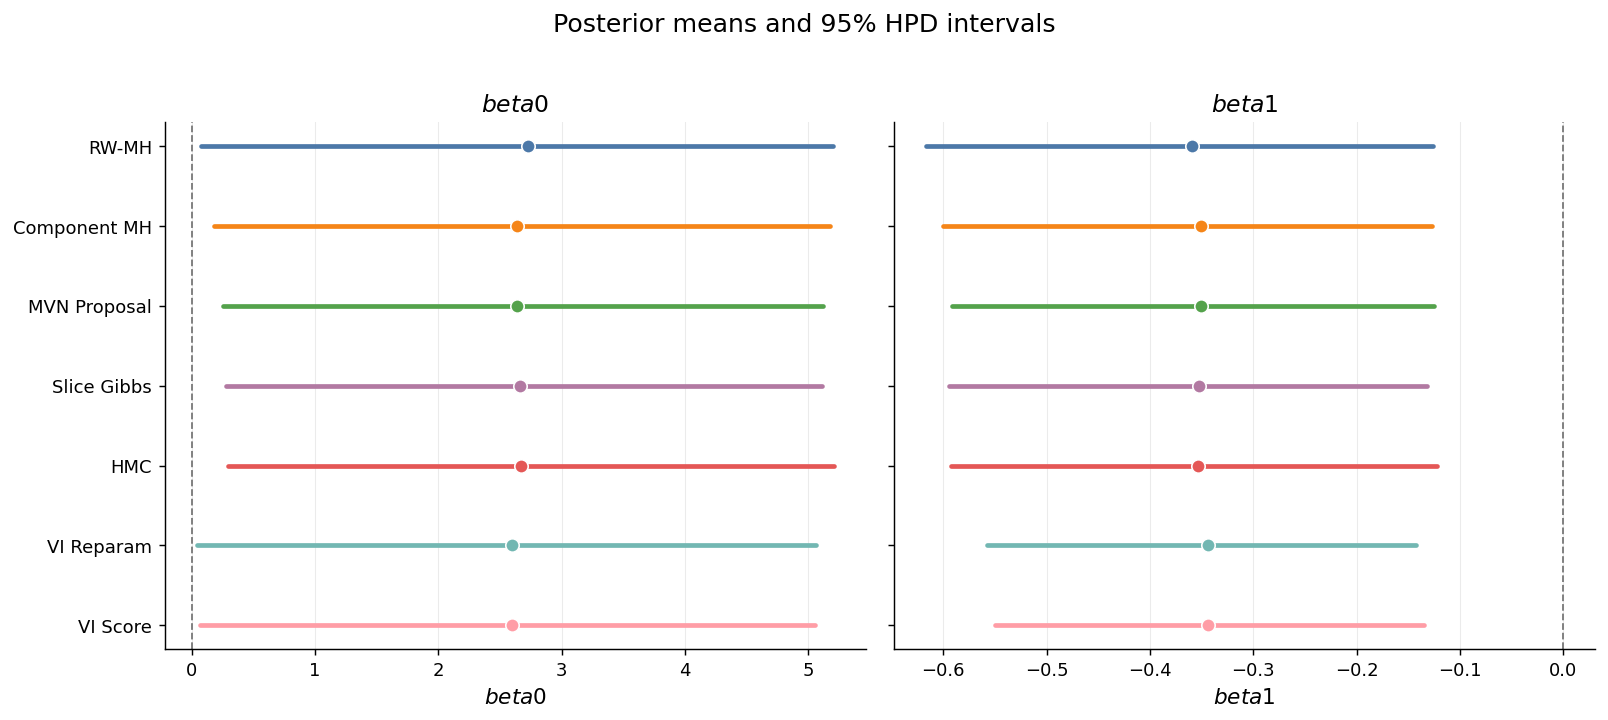

In [14]:
def plot_forest_two_panel(summary, save=True):
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.4), sharey=True)

    for ax, parameter in zip(axes, ["beta0", "beta1"]):
        df = summary[summary["parameter"] == parameter].copy().reset_index(drop=True)
        for col in ["mean", "HPD_low", "HPD_high"]:
            df[col] = pd.to_numeric(df[col], errors="coerce")

        y_pos = np.arange(len(df))[::-1]

        for i, row in df.iterrows():
            method = row["method"]
            color = method_colors.get(method, "#333333")
            mean, low, high = row["mean"], row["HPD_low"], row["HPD_high"]

            ax.plot([low, high], [y_pos[i], y_pos[i]], color=color,
                    linewidth=2.6, solid_capstyle="round")
            ax.scatter(mean, y_pos[i], s=55, color=color,
                       edgecolor="white", linewidth=0.9, zorder=3)

        ax.axvline(0, color="#777777", linestyle="--", linewidth=1)
        ax.set_xlabel(fr"${parameter}$")
        ax.set_title(fr"${parameter}$")
        ax.grid(axis="x", alpha=0.25)
        ax.grid(axis="y", alpha=0.0)

    axes[0].set_yticks(y_pos)
    axes[0].set_yticklabels([method_labels.get(m, m) for m in df["method"]])

    fig.suptitle("Posterior means and 95% HPD intervals", fontsize=14, y=1.02)
    plt.tight_layout()
    if save:
        save_fig("forest_two_panel")
    plt.show()


plot_forest_two_panel(all_summary)


## Cell 15：绘制 MCMC 后验密度图


Saved: final_results\figures\mcmc_density_two_panel.png
Saved: final_results\figures\mcmc_density_two_panel.pdf


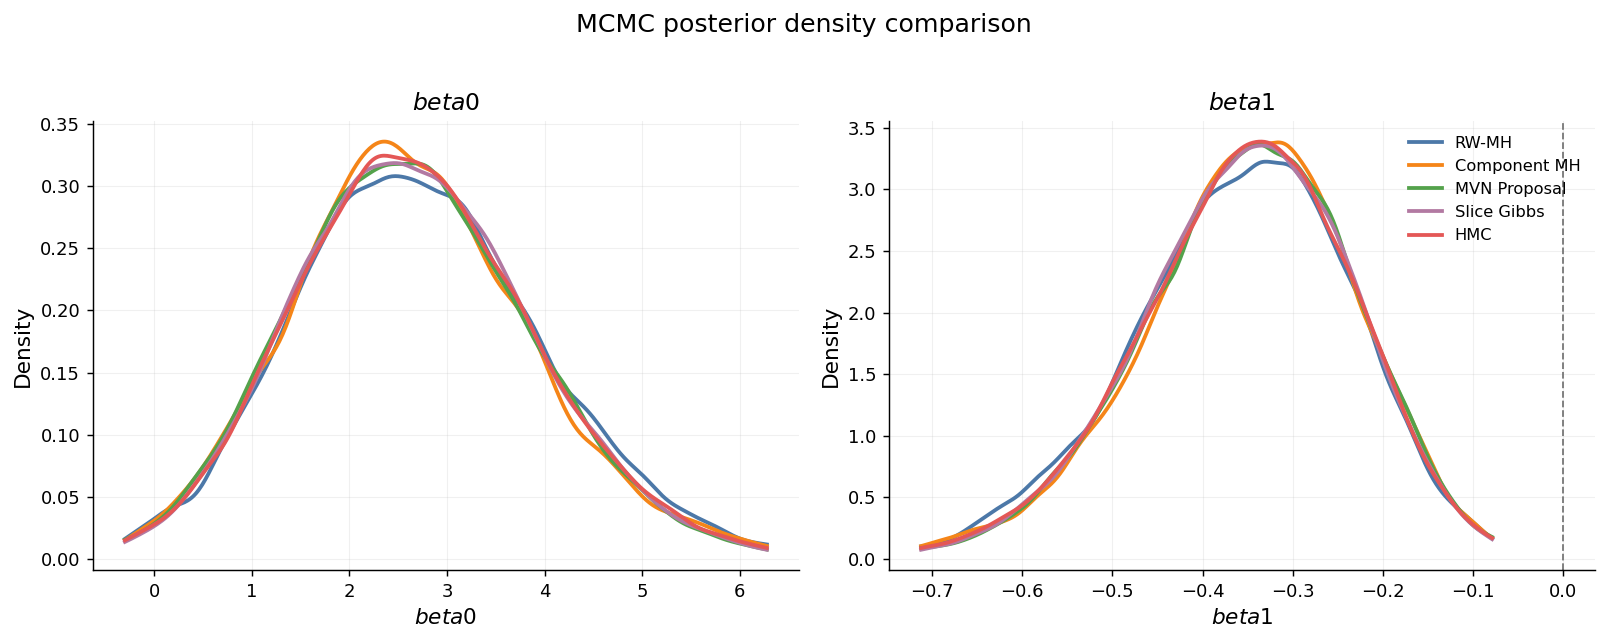

In [15]:
def plot_mcmc_density_two_panel(mcmc_chains, save=True):
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

    for ax, parameter, par_index in zip(axes, ["beta0", "beta1"], [0, 1]):
        all_samples = np.concatenate([
            get_pooled_samples(mcmc_chains[name])[:, par_index]
            for name in mcmc_chains
        ])
        low, high = np.quantile(all_samples, [0.005, 0.995])
        grid = np.linspace(low, high, 400)

        for name in ["RW", "Component", "MVN", "Slice", "HMC"]:
            samples = get_pooled_samples(mcmc_chains[name])[:, par_index]
            kde = gaussian_kde(samples)
            ax.plot(grid, kde(grid), color=method_colors[name],
                    label=method_labels[name], linewidth=2.1)

        if parameter == "beta1":
            ax.axvline(0, color="#777777", linestyle="--", linewidth=1)

        ax.set_xlabel(fr"${parameter}$")
        ax.set_ylabel("Density")
        ax.set_title(fr"${parameter}$")

    axes[1].legend(loc="upper right", fontsize=9)
    fig.suptitle("MCMC posterior density comparison", fontsize=14, y=1.02)
    plt.tight_layout()
    if save:
        save_fig("mcmc_density_two_panel")
    plt.show()


plot_mcmc_density_two_panel(mcmc_chains)


## Cell 16：绘制 MCMC 与变分推断的密度对比图


Saved: final_results\figures\mcmc_vi_density_two_panel.png
Saved: final_results\figures\mcmc_vi_density_two_panel.pdf


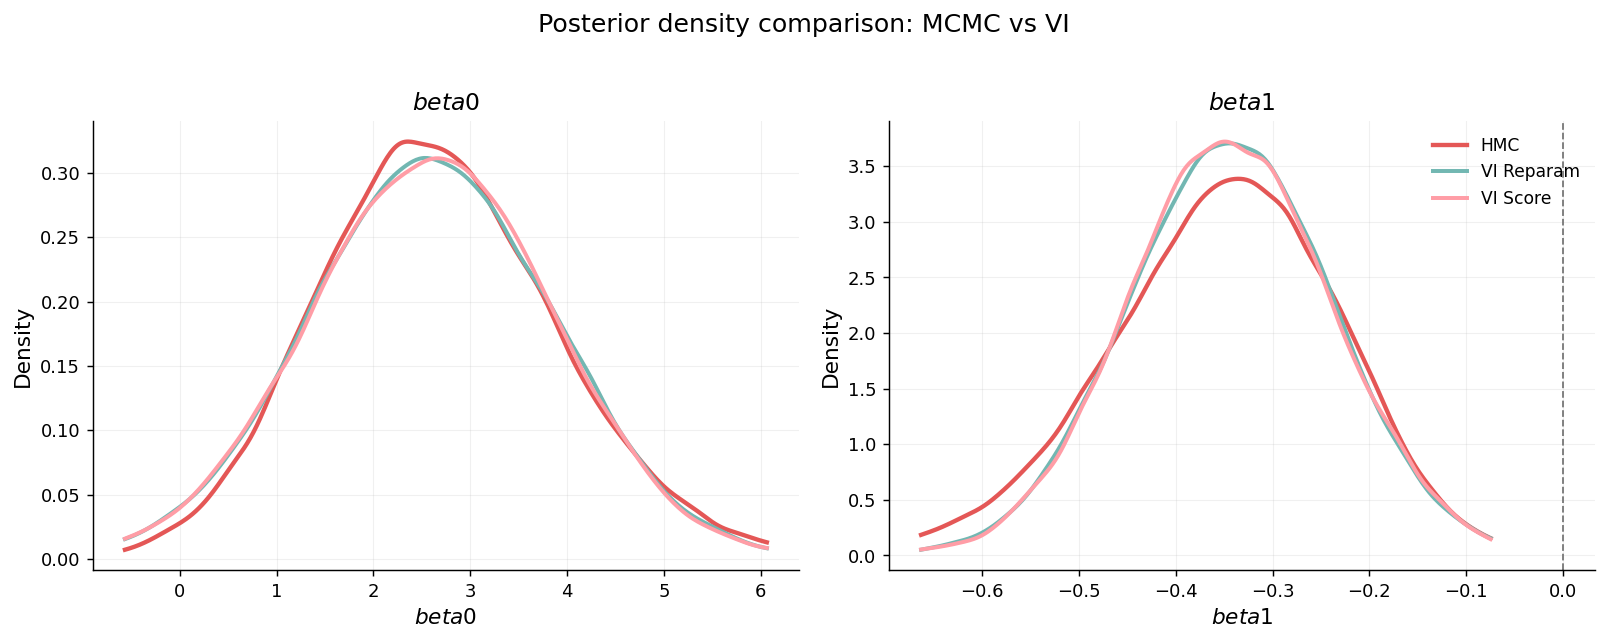

In [16]:
def plot_mcmc_vi_density_two_panel(mcmc_method="HMC", save=True):
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

    for ax, parameter, par_index in zip(axes, ["beta0", "beta1"], [0, 1]):
        mcmc_samples = get_pooled_samples(mcmc_chains[mcmc_method])[:, par_index]
        rep_samples = beta_rep[:, par_index]
        score_samples = beta_score[:, par_index]

        all_samples = np.concatenate([mcmc_samples, rep_samples, score_samples])
        low, high = np.quantile(all_samples, [0.005, 0.995])
        grid = np.linspace(low, high, 400)

        ax.plot(grid, gaussian_kde(mcmc_samples)(grid),
                color=method_colors[mcmc_method], label=method_labels[mcmc_method], linewidth=2.4)
        ax.plot(grid, gaussian_kde(rep_samples)(grid),
                color=method_colors["VI_Reparam"], label=method_labels["VI_Reparam"], linewidth=2.2)
        ax.plot(grid, gaussian_kde(score_samples)(grid),
                color=method_colors["VI_Score"], label=method_labels["VI_Score"], linewidth=2.2)

        if parameter == "beta1":
            ax.axvline(0, color="#777777", linestyle="--", linewidth=1)

        ax.set_xlabel(fr"${parameter}$")
        ax.set_ylabel("Density")
        ax.set_title(fr"${parameter}$")

    axes[1].legend(loc="upper right")
    fig.suptitle("Posterior density comparison: MCMC vs VI", fontsize=14, y=1.02)
    plt.tight_layout()
    if save:
        save_fig("mcmc_vi_density_two_panel")
    plt.show()


plot_mcmc_vi_density_two_panel(mcmc_method="HMC")


## Cell 17：绘制联合后验散点图


Saved: final_results\figures\scatter_three_panel.png
Saved: final_results\figures\scatter_three_panel.pdf


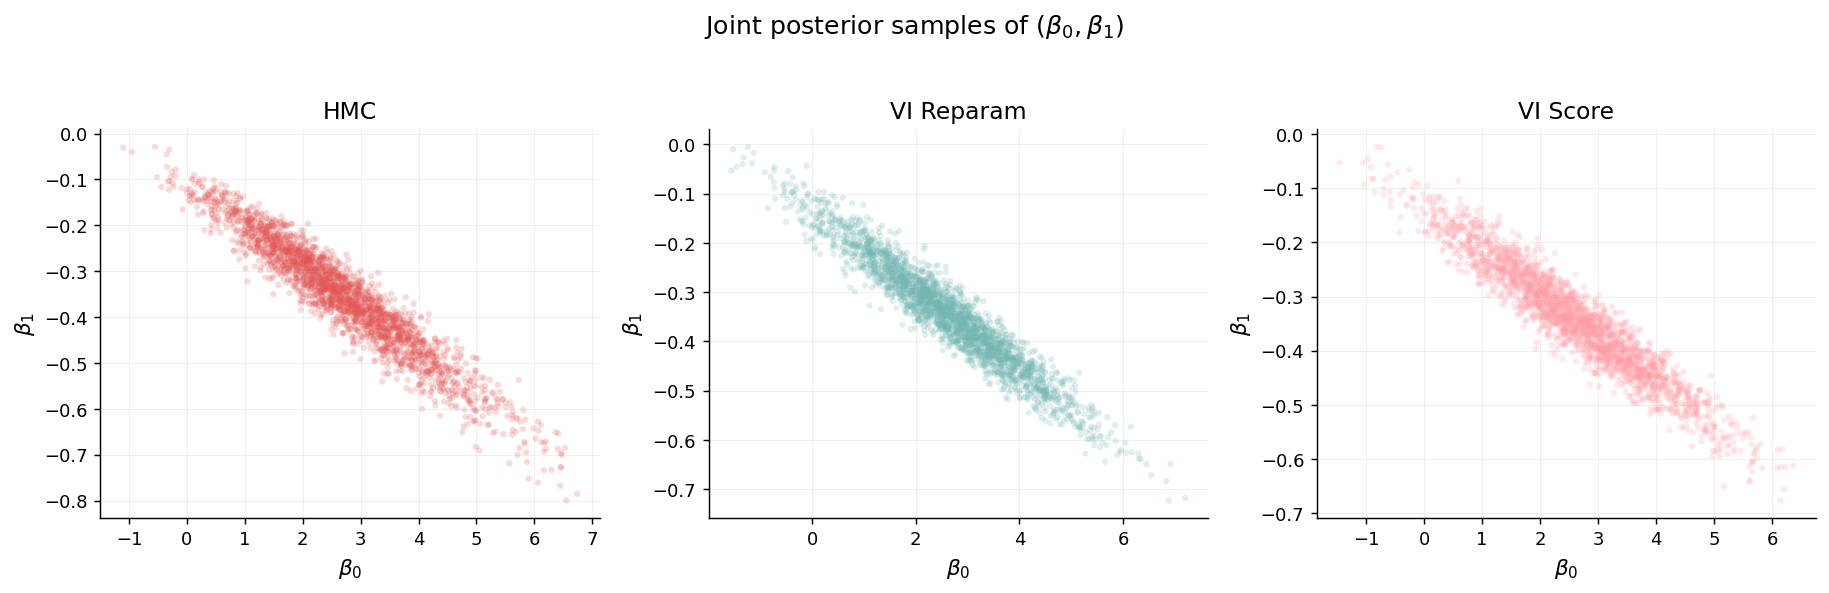

In [17]:
def plot_scatter_three_panel(save=True, n_plot=2500):
    hmc_samples = get_pooled_samples(mcmc_chains["HMC"])
    sample_dict = {
        "HMC": hmc_samples,
        "VI_Reparam": beta_rep,
        "VI_Score": beta_score
    }

    fig, axes = plt.subplots(1, 3, figsize=(14.2, 4.4))

    for ax, method in zip(axes, ["HMC", "VI_Reparam", "VI_Score"]):
        samples = sample_dict[method]
        if len(samples) > n_plot:
            idx = np.random.choice(len(samples), n_plot, replace=False)
            samples_plot = samples[idx]
        else:
            samples_plot = samples

        ax.scatter(samples_plot[:, 0], samples_plot[:, 1],
                   s=12, alpha=0.22, color=method_colors[method], edgecolors="none")
        ax.set_title(method_labels[method])
        ax.set_xlabel(r"$\beta_0$")
        ax.set_ylabel(r"$\beta_1$")

    fig.suptitle(r"Joint posterior samples of $(\beta_0,\beta_1)$", fontsize=14, y=1.03)
    plt.tight_layout()
    if save:
        save_fig("scatter_three_panel")
    plt.show()


plot_scatter_three_panel()


## Cell 18：绘制 HMC 的样本路径图和遍历均值图


Saved: final_results\figures\HMC_trace_running_beta1.png
Saved: final_results\figures\HMC_trace_running_beta1.pdf


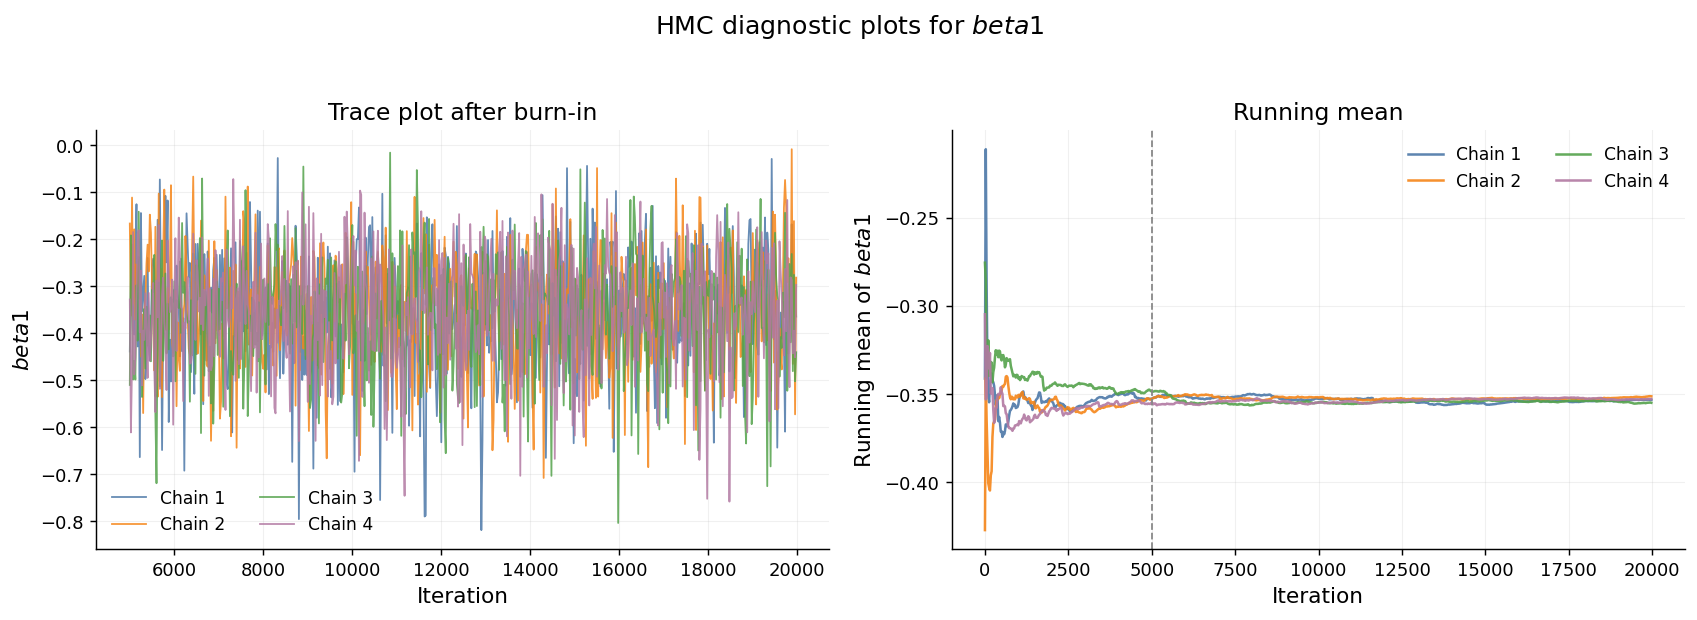

Saved: final_results\figures\HMC_trace_running_beta0.png
Saved: final_results\figures\HMC_trace_running_beta0.pdf


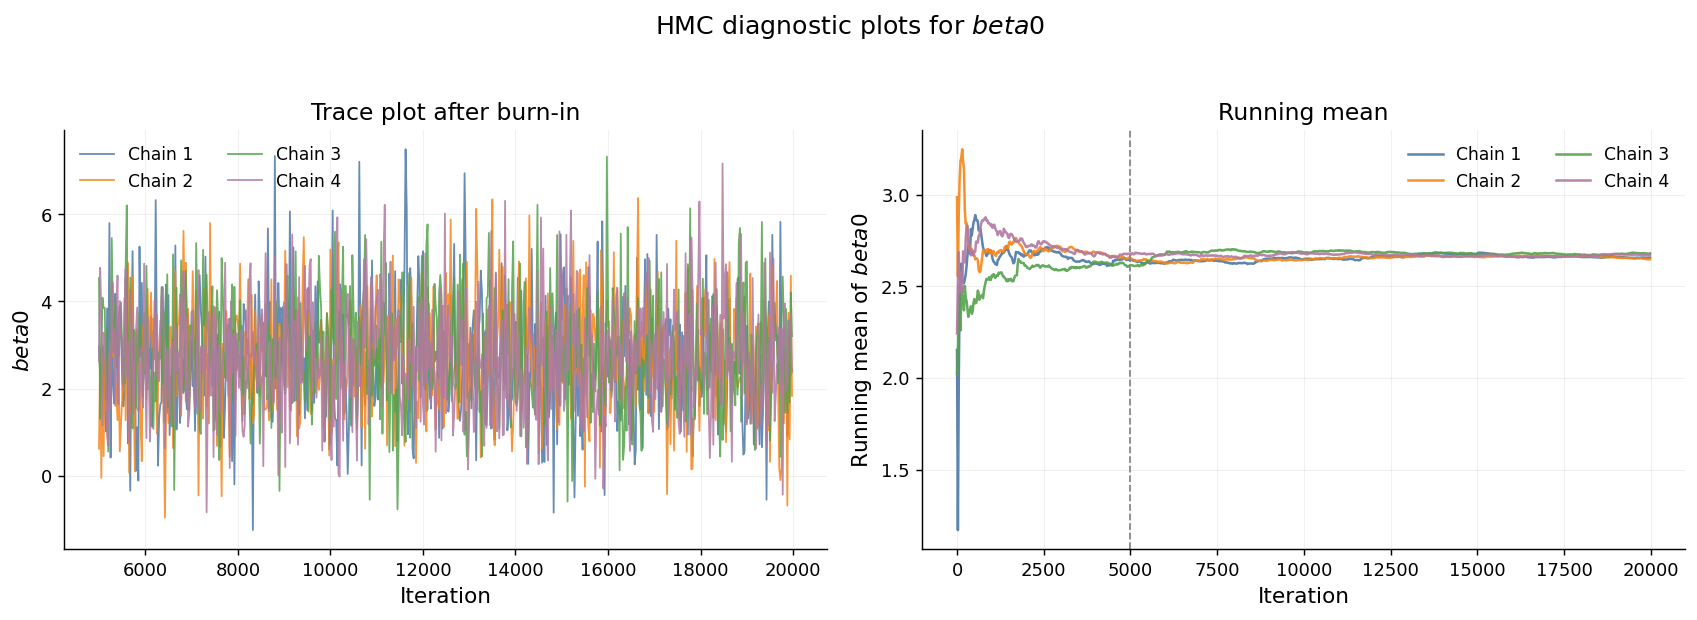

In [18]:
def plot_trace_and_running_mean(chains, method_name="HMC", parameter="beta1", plot_step=25, save=True):
    par_index = 0 if parameter == "beta0" else 1
    n_chains, n_iter, _ = chains.shape
    idx = np.arange(burn, n_iter, plot_step)

    fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.6))
    chain_palette = ["#4C78A8", "#F58518", "#54A24B", "#B279A2"]

    # trace plot after burn-in
    for c in range(n_chains):
        axes[0].plot(idx, chains[c, idx, par_index], color=chain_palette[c],
                     linewidth=1.0, alpha=0.85, label=f"Chain {c+1}")
    axes[0].set_title("Trace plot after burn-in")
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel(fr"${parameter}$")
    axes[0].legend(ncol=2)

    # running mean
    idx2 = np.arange(0, n_iter, plot_step)
    for c in range(n_chains):
        values = chains[c, :, par_index]
        running_mean = np.cumsum(values) / np.arange(1, n_iter + 1)
        axes[1].plot(idx2, running_mean[idx2], color=chain_palette[c],
                     linewidth=1.4, alpha=0.9, label=f"Chain {c+1}")
    axes[1].axvline(burn, color="#888888", linestyle="--", linewidth=1)
    axes[1].set_title("Running mean")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel(fr"Running mean of ${parameter}$")
    axes[1].legend(ncol=2)

    fig.suptitle(fr"{method_labels.get(method_name, method_name)} diagnostic plots for ${parameter}$", fontsize=14, y=1.03)
    plt.tight_layout()
    if save:
        save_fig(f"{method_name}_trace_running_{parameter}")
    plt.show()


plot_trace_and_running_mean(mcmc_chains["HMC"], "HMC", parameter="beta1")
plot_trace_and_running_mean(mcmc_chains["HMC"], "HMC", parameter="beta0")


## Cell 19：绘制 VI 的 ELBO 曲线


Saved: final_results\figures\vi_elbo.png
Saved: final_results\figures\vi_elbo.pdf


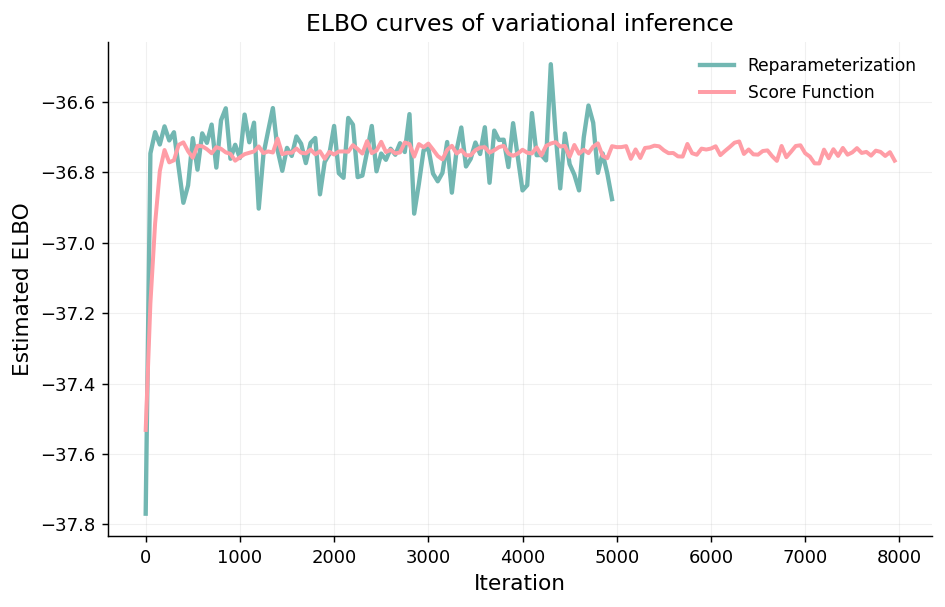

In [19]:
def plot_elbo(save=True):
    plt.figure(figsize=(7.4, 4.8))
    plt.plot(elbo_rep[:, 0], elbo_rep[:, 1], color=method_colors["VI_Reparam"],
             linewidth=2.4, label="Reparameterization")
    plt.plot(elbo_score[:, 0], elbo_score[:, 1], color=method_colors["VI_Score"],
             linewidth=2.2, label="Score Function")
    plt.xlabel("Iteration")
    plt.ylabel("Estimated ELBO")
    plt.title("ELBO curves of variational inference")
    plt.legend()
    plt.tight_layout()
    if save:
        save_fig("vi_elbo")
    plt.show()


plot_elbo()


## Cell 20：绘制后验患病概率曲线

基于 HMC 后验样本，计算每个智力测试分数下患病概率的后验均值和 95\% 后验区间。该图用于直观展示：智力测试分数越高，患病概率越低。


Saved: final_results\figures\posterior_probability_curve_HMC.png
Saved: final_results\figures\posterior_probability_curve_HMC.pdf


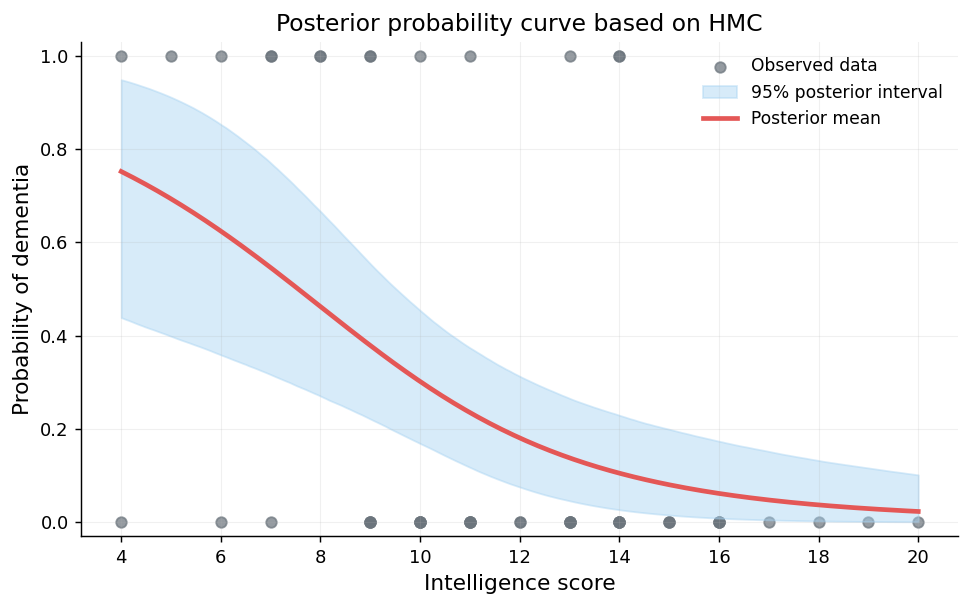

In [20]:
def plot_probability_curve(beta_samples, save=True):
    x_grid = np.linspace(x.min(), x.max(), 200)

    beta0 = beta_samples[:, 0].reshape(-1, 1)
    beta1 = beta_samples[:, 1].reshape(-1, 1)
    eta = beta0 + beta1 * x_grid.reshape(1, -1)
    prob = 1 / (1 + np.exp(-eta))

    prob_mean = prob.mean(axis=0)
    prob_low = np.quantile(prob, 0.025, axis=0)
    prob_high = np.quantile(prob, 0.975, axis=0)

    plt.figure(figsize=(7.6, 4.8))
    plt.scatter(x, y, s=34, alpha=0.72, color="#6C757D", label="Observed data")
    plt.fill_between(x_grid, prob_low, prob_high, color="#A7D3F2", alpha=0.45,
                     label="95% posterior interval")
    plt.plot(x_grid, prob_mean, color=method_colors["HMC"], linewidth=2.6,
             label="Posterior mean")
    plt.xlabel("Intelligence score")
    plt.ylabel("Probability of dementia")
    plt.title("Posterior probability curve based on HMC")
    plt.ylim(-0.03, 1.03)
    plt.legend()
    plt.tight_layout()
    if save:
        save_fig("posterior_probability_curve_HMC")
    plt.show()


hmc_samples = get_pooled_samples(mcmc_chains["HMC"])
plot_probability_curve(hmc_samples)
